# 02 — Test the construction, then predict where the factor goes

Run `01_build_factor` first (it saves the CSVs this notebook reads).

### Part A — decompose a move into component contributions

The factor is the average of six signed z-scores, so the change in the
factor between any two dates decomposes EXACTLY:

```
factor_change = sum over components of ( signed_z_change / 6 )
share_i       = component i's piece / total change
```

No modeling involved — just arithmetic. We apply it to the biggest recent
move: from the post-June-FOMC peak to today.

**Why this doubles as a test:** in mock mode the synthetic data plants a
spike-and-unwind with KNOWN component shares (see `_UNWIND_SHARES` in
`bbg.py`). If the decomposition below recovers roughly those numbers,
the construction and attribution code are working — so when you run on
real Bloomberg data, you can trust what it tells you.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg

signed_z = pd.read_csv("signed_zscores.csv", index_col=0, parse_dates=True)
factor = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]

fomc_date = pd.Timestamp(2026, 6, 17)

### Size of the move: peak after the June FOMC vs today

In [2]:
after_fomc = factor[factor.index >= fomc_date]
peak_date = after_fomc.idxmax()
peak_value = after_fomc.max()
latest_value = factor.iloc[-1]

print(f"Peak after June FOMC : {peak_value:+.2f} on {peak_date.date()}")
print(f"Latest               : {latest_value:+.2f} on {factor.index[-1].date()}")
print(f"Move                 : {latest_value - peak_value:+.2f}")

Peak after June FOMC : +2.13 on 2026-06-19
Latest               : -0.75 on 2026-07-09
Move                 : -2.88


### Decomposition: who drove it?

In [3]:
z_at_peak = signed_z.loc[peak_date]
z_now = signed_z.iloc[-1]

contribution = (z_now - z_at_peak) / 6.0       # each component's piece
share = contribution / contribution.sum()      # as % of the total move

# in mock mode we know the planted ground truth - show it side by side
planted = {}
if bbg.MOCK_MODE:
    key_map = {"yield_30y": "30y", "dxy": "dxy", "infl_swap_5y": "swap",
               "fomc_hike": "fomc", "oil": "oil", "gold": "gold"}
    planted = {name: bbg._UNWIND_SHARES[key] for name, key in key_map.items()}

header = f"{'component':<14}{'share':>8}" + ("{:>10}".format("planted") if planted else "")
print(header)
for name in share.sort_values().index:
    line = f"{name:<14}{share[name]:>7.0%}"
    if planted:
        line += f"{planted[name]:>9.0%}"
    print(line)
print(f"\nTotal factor change: {contribution.sum():+.2f}")

component        share   planted
dxy               11%      17%
gold              11%       3%
infl_swap_5y      18%      17%
oil               18%      16%
yield_30y         20%      31%
fomc_hike         20%      16%

Total factor change: -2.88


In mock mode the recovered shares should land near the planted ones
(not exactly — the EWM z-score adapts its own mean/std during the move,
which compresses the biggest movers a little). On real data, read this
table as attribution: which markets are repricing Fed credibility.

---
### Part B — predicting where the factor goes next

The factor is a z-score, so by construction it is **mean-reverting**:
it cannot drift to +10, the ewm mean/std would absorb the move. The
simplest honest model of a mean-reverting series is **AR(1)**:

```
factor_tomorrow = a + b * factor_today + noise
```

`b` (between 0 and 1) says how much of today survives to tomorrow.
From `b` we get the **half-life of a shock**: how many days until half
of a spike has decayed = `ln(0.5) / ln(b)`.

In [4]:
y = factor.dropna()
today = y.values[:-1]      # x: factor today
tomorrow = y.values[1:]    # y: factor tomorrow

b, a = np.polyfit(today, tomorrow, 1)   # fit tomorrow = a + b*today
residuals = tomorrow - (a + b * today)
noise_std = residuals.std()

half_life = np.log(0.5) / np.log(b)
long_run_mean = a / (1 - b)

print(f"AR(1) fit: tomorrow = {a:+.4f} + {b:.4f} * today")
print(f"Shock half-life : {half_life:.1f} business days")
print(f"Long-run mean   : {long_run_mean:+.2f}")
print(f"Daily noise std : {noise_std:.3f}")

AR(1) fit: tomorrow = +0.0141 + 0.8527 * today
Shock half-life : 4.4 business days
Long-run mean   : +0.10
Daily noise std : 0.464


### Fan chart: next 21 business days

We iterate the AR(1) forward for the central path. Uncertainty grows
with horizon: the k-step-ahead standard deviation for an AR(1) is
`noise_std * sqrt( (1 - b^(2k)) / (1 - b^2) )` — it grows fast at first,
then flattens at the series' natural volatility. We shade ±1 and ±2 of
that around the path.

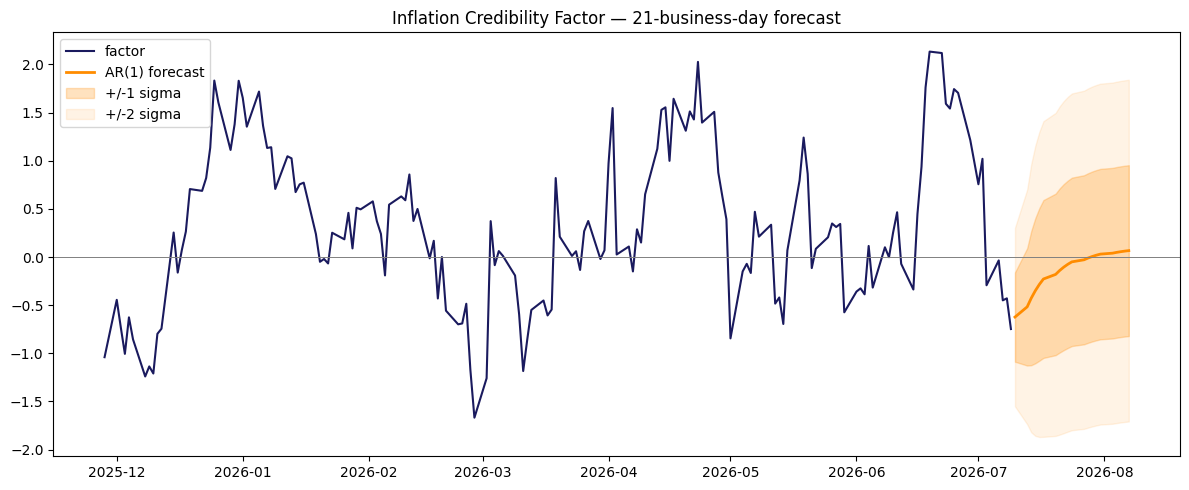

Forecast in 21 days: +0.07  (from -0.75 today, reverting toward +0.10)


In [5]:
HORIZON = 21
last_value = y.iloc[-1]
last_date = y.index[-1]

path, spread = [], []
value = last_value
for k in range(1, HORIZON + 1):
    value = a + b * value
    path.append(value)
    spread.append(noise_std * np.sqrt((1 - b ** (2 * k)) / (1 - b ** 2)))

future_dates = pd.bdate_range(last_date, periods=HORIZON + 1)[1:]
path = np.array(path)
spread = np.array(spread)

history = y.iloc[-160:]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.index, history.values, color="#1a1a5e", label="factor")
ax.plot(future_dates, path, color="darkorange", linewidth=2, label="AR(1) forecast")
ax.fill_between(future_dates, path - spread, path + spread,
                color="darkorange", alpha=0.25, label="+/-1 sigma")
ax.fill_between(future_dates, path - 2 * spread, path + 2 * spread,
                color="darkorange", alpha=0.10, label="+/-2 sigma")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_title("Inflation Credibility Factor — 21-business-day forecast")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("factor_forecast.png", dpi=120)
plt.show()

print(f"Forecast in 21 days: {path[-1]:+.2f}  "
      f"(from {last_value:+.2f} today, reverting toward {long_run_mean:+.2f})")

### How to read this — and what the model CANNOT tell you

- The statistical pull is **toward the mean**: after a big unwind the
  factor sits low and AR(1) just says "expect drift back toward average,
  +/- the shaded band".
- What actually moves it next is **policy action**: if the Fed follows
  hawkish words with a hike (watch the `fomc_hike` component), credibility
  rebuilds and the factor climbs; if inflation pressure builds (oil,
  swaps) while the Fed sits still, it keeps bleeding.
- So use the fan chart as the "no news" base case, and the component
  stack from notebook 01 to see which leg is confirming or breaking
  that base case each day.